<a href="https://colab.research.google.com/github/Idir-Z/airsim-drone-obstacle/blob/main/airsimDrones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 - Download dataset straight from Kaggle into Colab
!pip install kaggle

# Upload your kaggle.json API key when prompted
from google.colab import files
files.upload()  # upload kaggle.json (download it from kaggle.com → Settings → API)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset (replace with your actual dataset slug)
!kaggle datasets download -d lukpellant/droneflight-obs-avoidanceairsimrgbdepth10k-320x320 --unzip -p /content/drone_dataset

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/lukpellant/droneflight-obs-avoidanceairsimrgbdepth10k-320x320
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.97G/1.97G [00:16<00:00, 129MB/s]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/drone_dataset'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = '/content/drone_dataset/data_collected_potential_final_v58_mod25_320x320_cmds'

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models

In [ ]:
print(os.listdir(dataset_path))

['commands', 'depth', 'rgb']


RGB size: (320, 320)
Depth shape: (320, 320)
Command: [  1.2231183   0.         -0.3599569 -11.846762 ]


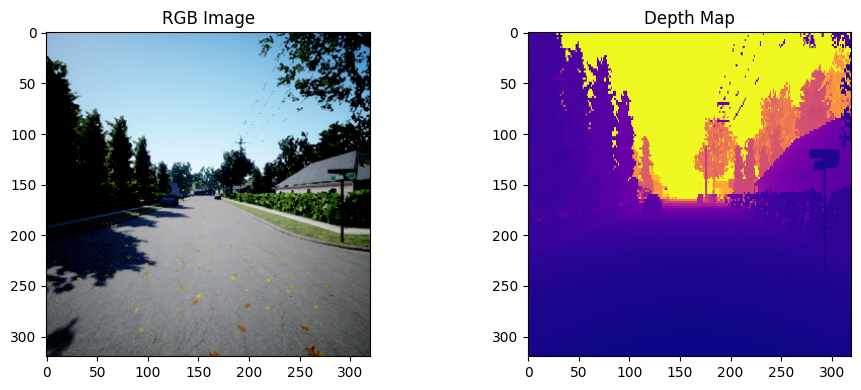

In [ ]:
# Load one sample
idx = 0
sample_id = f'{idx:06d}'  # formats as '000000'

rgb = Image.open(f'{dataset_path}/rgb/{sample_id}.png')
depth = np.load(f'{dataset_path}/depth/{sample_id}.npy')
command = np.load(f'{dataset_path}/commands/{sample_id}.npy')

print(f'RGB size: {rgb.size}')          # should be (320, 320)
print(f'Depth shape: {depth.shape}')    # should be (320, 320) or (1, 320, 320)
print(f'Command: {command}')            # should be 4 values: vx, vy, vz, yaw_rate

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(rgb)
axes[0].set_title('RGB Image')
axes[1].imshow(depth, cmap='plasma')
axes[1].set_title('Depth Map')
plt.tight_layout()
plt.show()

In [ ]:
class DroneDataset(Dataset):
    def __init__(self, dataset_path, num_samples=10000):
        self.dataset_path = dataset_path
        self.num_samples = num_samples

        # RGB transform: resize to 224x224 (ResNet expects this), normalize with ImageNet stats
        self.rgb_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),  # converts to [0,1] and shape (C, H, W)
            transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                                 std=[0.229, 0.224, 0.225])
        ])

        # Depth transform: just resize and convert to tensor
        self.depth_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()  # shape becomes (1, 224, 224)
        ])

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        sample_id = f'{idx:06d}'

        # Load RGB
        rgb = Image.open(f'{self.dataset_path}/rgb/{sample_id}.png').convert('RGB')
        rgb = self.rgb_transform(rgb)

        # Load Depth
        depth = np.load(f'{self.dataset_path}/depth/{sample_id}.npy')
        depth = depth.squeeze()                   # make sure it's 2D (H, W)
        depth = Image.fromarray(depth.astype(np.float32))  # convert to PIL for transform
        depth = self.depth_transform(depth)       # shape: (1, 224, 224)

        # Load Command
        command = np.load(f'{self.dataset_path}/commands/{sample_id}.npy')
        command = torch.tensor(command, dtype=torch.float32)  # shape: (4,)

        return rgb, depth, command

In [ ]:
full_dataset = DroneDataset(dataset_path)

# Split: 80% train, 10% val, 10% test
train_size = 8000
val_size   = 1000
test_size  = 1000

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')

Train: 8000 | Val: 1000 | Test: 1000


In [ ]:
class DroneModel(nn.Module):
    def __init__(self):
        super(DroneModel, self).__init__()
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        # Remove the last classification layer — we just want features
        self.rgb_branch = nn.Sequential(*list(resnet.children())[:-1])
        # Output shape: (batch, 512, 1, 1)
        self.depth_branch = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 112x112
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 56x56
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 28x28
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # output: (batch, 128, 1, 1)
        )

        # --- Fusion + prediction head ---
        # 512 (RGB) + 128 (depth) = 640 features combined
        self.head = nn.Sequential(
            nn.Linear(640, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 4)  # 4 outputs: vx, vy, vz, yaw_rate
        )

    def forward(self, rgb, depth):
        rgb_feat   = self.rgb_branch(rgb).flatten(1)    # (batch, 512)
        depth_feat = self.depth_branch(depth).flatten(1) # (batch, 128)
        combined   = torch.cat([rgb_feat, depth_feat], dim=1)  # (batch, 640)
        return self.head(combined)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = DroneModel().to(device)
print(model)

Using device: cuda
DroneModel(
  (rgb_branch): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 25
best_val_loss = float('inf')
patience = 5          # stop if val loss doesn't improve for 5 epochs
patience_counter = 0

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0
    for rgb, depth, commands in train_loader:
        rgb, depth, commands = rgb.to(device), depth.to(device), commands.to(device)

        optimizer.zero_grad()          # clear old gradients
        preds = model(rgb, depth)      # forward pass
        loss = criterion(preds, commands)  # compute loss
        loss.backward()                # backprop
        optimizer.step()               # update weights

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0
    with torch.no_grad():  # no gradient needed during validation
        for rgb, depth, commands in val_loader:
            rgb, depth, commands = rgb.to(device), depth.to(device), commands.to(device)
            preds = model(rgb, depth)
            val_loss += criterion(preds, commands).item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

Epoch 1/25 | Train Loss: 70.8757 | Val Loss: 26.3687
Epoch 2/25 | Train Loss: 28.2094 | Val Loss: 22.6178
Epoch 3/25 | Train Loss: 15.7707 | Val Loss: 16.7302
Epoch 4/25 | Train Loss: 11.6531 | Val Loss: 15.1071
Epoch 5/25 | Train Loss: 8.7371 | Val Loss: 16.1639
Epoch 6/25 | Train Loss: 7.0137 | Val Loss: 14.4678
Epoch 7/25 | Train Loss: 6.7979 | Val Loss: 12.4155
Epoch 8/25 | Train Loss: 5.3731 | Val Loss: 13.3196
Epoch 9/25 | Train Loss: 4.6368 | Val Loss: 12.8597
Epoch 10/25 | Train Loss: 4.2896 | Val Loss: 13.5235
Epoch 11/25 | Train Loss: 4.2908 | Val Loss: 12.3202
Epoch 12/25 | Train Loss: 3.9482 | Val Loss: 13.1138
Epoch 13/25 | Train Loss: 3.6054 | Val Loss: 12.4299
Epoch 14/25 | Train Loss: 3.1295 | Val Loss: 13.0384
Epoch 15/25 | Train Loss: 3.3234 | Val Loss: 11.3677
Epoch 16/25 | Train Loss: 2.9243 | Val Loss: 11.7727
Epoch 17/25 | Train Loss: 2.6941 | Val Loss: 12.7330
Epoch 18/25 | Train Loss: 2.6722 | Val Loss: 11.7357
Epoch 19/25 | Train Loss: 2.7176 | Val Loss: 12.435

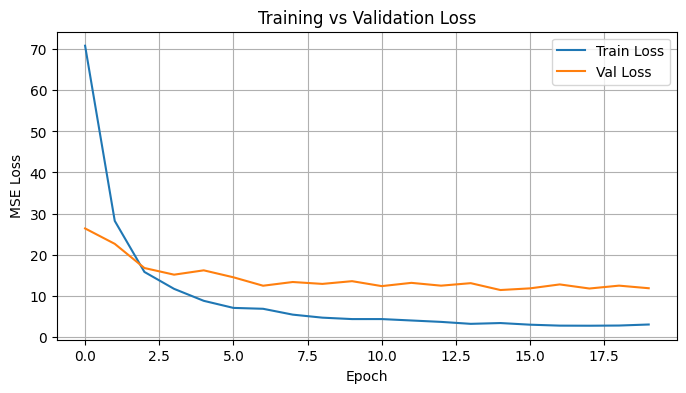

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Load best saved model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for rgb, depth, commands in test_loader:
        rgb, depth = rgb.to(device), depth.to(device)
        preds = model(rgb, depth)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(commands.numpy())

all_preds   = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

mae = np.mean(np.abs(all_preds - all_targets), axis=0)
print(f'MAE per command:')
print(f'  vx:       {mae[0]:.4f}')
print(f'  vy:       {mae[1]:.4f}')
print(f'  vz:       {mae[2]:.4f}')
print(f'  yaw_rate: {mae[3]:.4f}')
print(f'  Overall MAE: {mae.mean():.4f}')

MAE per command:
  vx:       0.3711
  vy:       0.0382
  vz:       0.2302
  yaw_rate: 4.2847
  Overall MAE: 1.2311


In [ ]:
import numpy as np

np.save('all_preds.npy', all_preds)
np.save('all_targets.npy', all_targets)

# or as CSV if you prefer readable format
import pandas as pd
df = pd.DataFrame(
    np.hstack([all_targets, all_preds]),
    columns=['true_vx','true_vy','true_vz','true_yaw',
             'pred_vx','pred_vy','pred_vz','pred_yaw']
)
df.to_csv('predictions.csv', index=False)

In [ ]:
import json

metrics = {
    'mae_vx':       float(mae[0]),
    'mae_vy':       float(mae[1]),
    'mae_vz':       float(mae[2]),
    'mae_yaw_rate': float(mae[3]),
    'overall_mae':  float(mae.mean())
}
with open('results.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("Results saved to results.json")

Results saved to results.json


In [ ]:


# then save directly to your Drive
import json
with open('/content/drive/MyDrive/results.json', 'w') as f:
    json.dump(metrics, f, indent=4)

import torch
torch.save(model.state_dict(), '/content/drive/MyDrive/best_model.pth')

import numpy as np
np.save('/content/drive/MyDrive/all_preds.npy', all_preds)
np.save('/content/drive/MyDrive/all_targets.npy', all_targets)

# plot
plt.savefig('/content/drive/MyDrive/predictions_plot.png', dpi=150)

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files

files.download('results.json')
files.download('best_model.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>